# Figure: Variant-effect logSED saliency track

For a single yeast gene we perform an exhaustive single-nucleotide *in-silico* mutagenesis (ISM) over a small window near the transcription start site. At every position we substitute each of the three alternative bases, predict reference- and alternate-allele coverage with the released 8-fold **Shorkie** finetuned ensemble, and reduce the change in predicted gene-body expression to a single **logSED** score: `log2(Σ_alt_bins + 1) − log2(Σ_ref_bins + 1)`. Plotting the per-position maximum |logSED| produces a variant-effect saliency track that highlights the bases the model considers most regulatory.

**Reproduces:** the variant-effect logSED scoring used throughout the eQTL/MPRA benchmarks, generalized into a per-position saliency scan.

**Upstream:** Runs end-to-end from released data (the published Shorkie ensemble + R64 genome). No intermediate artifact is required.

**Requires:** the `yeast_ml` conda env with the package installed (`pip install -e .`); a **GPU** is strongly recommended (each scan position requires a forward pass of the full ensemble).

**Source script:** ported and generalized from `minimal_example/run_shorkie_variant.py` (model loading, window placement, `logSED`) and the scoring loop in `scripts/04_analysis/shorkie/eqtl/2_variant_scoring/score_variants_shorkie.py`.

In [1]:
import json

import numpy as np
import pandas as pd
import pysam
import matplotlib.pyplot as plt

from baskerville import gene as bgene

from shorkie import config
from shorkie.models.ensemble import load_ensemble, make_input, ensemble_predict, logSED

NT = ["A", "C", "G", "T"]
NT_IX = {b: i for i, b in enumerate(NT)}

In [2]:
# Resolve every path through the config layer (no hardcoded absolute paths).
config.load()

model_dir    = str(config.path("models.shorkie_finetuned"))
params_file  = str(config.path("models.shorkie_finetuned") / "params.json")
targets_file = str(config.path("datasets.targets_sheet"))
fasta_file   = str(config.path("genome.fasta"))
gtf_file     = str(config.path("genome.gtf"))
num_folds    = config.get("models.num_folds", 8)

SEQ_LEN = 16384
print("model_dir   :", model_dir)
print("params_file :", params_file)
print("targets     :", targets_file)
print("num_folds   :", num_folds)

model_dir   : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/seq_experiment/exp_histone__chip_exo__rna_seq_no_norm_5215_tracks/16bp/self_supervised_unet_small_bert_drop
params_file : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/seq_experiment/exp_histone__chip_exo__rna_seq_no_norm_5215_tracks/16bp/self_supervised_unet_small_bert_drop/params.json
targets     : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/seq_experiment/exp_histone__chip_exo__rna_seq_no_norm_5215_tracks/16bp/cleaned_sheet.txt
num_folds   : 8


In [3]:
# Targets sheet -> track index used to slice the ensemble outputs.
targets_df   = pd.read_csv(targets_file, index_col=0, sep="\t")
target_index = targets_df.index
print("Tracks:", len(target_index))

# Load the released 8-fold Shorkie ensemble (GPU recommended).
models = load_ensemble(model_dir, params_file, target_index, num_folds=num_folds)
m0 = models[0]

# Genomic resources.
fasta         = pysam.Fastafile(fasta_file)
transcriptome = bgene.Transcriptome(gtf_file)

Tracks: 5215


2026-06-19 04:46:08.874855: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 04:46:10.643092: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 04:46:10.643142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 04:46:11.090384: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 04:46:11.604808: I tensorflow/core/platform/cpu_feature_guar

2026-06-19 04:46:13.828383: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


  Loading fold 0: /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/seq_experiment/exp_histone__chip_exo__rna_seq_no_norm_5215_tracks/16bp/self_supervised_unet_small_bert_drop/train/f0c0/train/model_best.h5


2026-06-19 04:46:18.010440: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79194 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:b1:00.0, compute capability: 8.0


...


  Weight multihead_attention_1/multihead_attention_1/embedding_layer/kernel:0: (384, 384)


  Weight multihead_attention_1/multihead_attention_1/k_layer/kernel:0: (384, 256)


  Weight multihead_attention_1/multihead_attention_1/q_layer/kernel:0: (384, 256)
  Weight multihead_attention_1/multihead_attention_1/r_k_layer/kernel:0: (32, 256)
  Weight multihead_attention_1/multihead_attention_1/r_r_bias:0: (1, 4, 1, 64)
  Weight multihead_attention_1/multihead_attention_1/r_w_bias:0: (1, 4, 1, 64)
  Weight multihead_attention_1/multihead_attention_1/v_layer/kernel:0: (384, 384)
  Weight multihead_attention_2/multihead_attention_2/embedding_layer/bias:0: (384,)
  Weight multihead_attention_2/multihead_attention_2/embedding_layer/kernel:0: (384, 384)
  Weight multihead_attention_2/multihead_attention_2/k_layer/kernel:0: (384, 256)
  Weight multihead_attention_2/multihead_attention_2/q_layer/kernel:0: (384, 256)


  Weight multihead_attention_2/multihead_attention_2/r_k_layer/kernel:0: (32, 256)
  Weight multihead_attention_2/multihead_attention_2/r_r_bias:0: (1, 4, 1, 64)
  Weight multihead_attention_2/multihead_attention_2/r_w_bias:0: (1, 4, 1, 64)
  Weight multihead_attention_2/multihead_attention_2/v_layer/kernel:0: (384, 384)
  Weight multihead_attention_3/multihead_attention_3/embedding_layer/bias:0: (384,)
  Weight multihead_attention_3/multihead_attention_3/embedding_layer/kernel:0: (384, 384)
  Weight multihead_attention_3/multihead_attention_3/k_layer/kernel:0: (384, 256)
  Weight multihead_attention_3/multihead_attention_3/q_layer/kernel:0: (384, 256)
  Weight multihead_attention_3/multihead_attention_3/r_k_layer/kernel:0: (32, 256)
  Weight multihead_attention_3/multihead_attention_3/r_r_bias:0: (1, 4, 1, 64)
  Weight multihead_attention_3/multihead_attention_3/r_w_bias:0: (1, 4, 1, 64)
  Weight multihead_attention_3/multihead_attention_3/v_layer/kernel:0: (384, 384)
  Weight multihe

	 (build_ensemble) * sequence.shape:  (None, 16384, 170)
	 (build_ensemble) shift_bool:  False
	 (build_ensemble) ensemble_rc:  True


In [4]:
# Pick a representative gene and locate it in the transcriptome.
GENE = "YAL016C-B"

keys = [k for k in transcriptome.genes if GENE in k]
assert keys, f"Gene {GENE!r} not found in GTF"
gene = transcriptome.genes[keys[0]]

chrom = gene.chrom if gene.chrom.startswith("chr") else "chr" + gene.chrom
gene_start, gene_end = gene.span()
gc = gene.midpoint()
print(f"Gene {GENE}: {chrom}:{gene_start}-{gene_end}  (midpoint {gc})")

# Mirror the window placement of run_shorkie_variant.py: center the gene body in
# the cropped output while keeping the scan window inside the 16 kb input.
off  = m0.model_strides[0] * m0.target_crops[0]
olen = m0.model_strides[0] * m0.target_lengths[0]

# Scan a small window just upstream of / across the TSS-proximal region.
SCAN_HALF = 30                         # +/- bp around the anchor -> 61 positions
anchor = gc                            # anchor the scan at the gene midpoint

lo = max(anchor - SEQ_LEN + 1, gc - off - olen + 1)
hi = min(anchor - 1,           gc - off)
start = int((lo + hi) // 2) if lo <= hi else int(gc - SEQ_LEN // 2)
end = start + SEQ_LEN

gene_slice = gene.output_slice(start + off, int(olen), m0.model_strides[0], False)
print(f"Input window: {chrom}:{start}-{end}  |  output bins in gene slice: {gene_slice}")

Gene YAL016C-B: chrI:124306-124492  (midpoint 124398)
Input window: chrI:116206-132590  |  output bins in gene slice: [442 443 444 445 446 447 448 449 450 451 452 453]


In [5]:
# Reference one-hot input and its reference logSED baseline (= 0 by construction).
x_ref = make_input(fasta, chrom, start, end, SEQ_LEN)
y_ref = ensemble_predict(models, x_ref)
x_ref_np = x_ref.numpy()

# Scan positions (genomic, 1-based) around the anchor.
scan_positions = list(range(anchor - SCAN_HALF, anchor + SCAN_HALF + 1))

# For each position x each alternate base, mutate the ref one-hot, predict, score.
logsed_grid = np.full((len(scan_positions), 4), np.nan, dtype=np.float32)
ref_bases   = []

for i, pos in enumerate(scan_positions):
    ci = pos - start - 1                      # 0-based index inside the window
    if not (0 <= ci < SEQ_LEN):
        ref_bases.append("N")
        continue
    ref_ix = int(np.argmax(x_ref_np[ci, :4]))
    ref_bases.append(NT[ref_ix] if x_ref_np[ci, :4].sum() > 0 else "N")
    for alt_ix in range(4):
        if alt_ix == ref_ix:
            logsed_grid[i, alt_ix] = 0.0      # alt == ref -> no effect
            continue
        x_alt = np.copy(x_ref_np)
        x_alt[ci, :4] = 0.0
        x_alt[ci, alt_ix] = 1.0
        y_alt = ensemble_predict(models, x_alt)
        logsed_grid[i, alt_ix] = logSED(y_ref, y_alt, gene_slice)

print("Scanned", len(scan_positions), "positions x 3 alt bases.")

2026-06-19 04:47:18.962838: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


2026-06-19 04:47:19.824672: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


2026-06-19 04:47:21.083224: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Scanned 61 positions x 3 alt bases.


In [6]:
# Per-position saliency = the strongest single-nucleotide effect at each base.
abs_grid     = np.abs(np.nan_to_num(logsed_grid))
max_abs      = abs_grid.max(axis=1)                       # magnitude of the strongest alt
argmax_alt   = abs_grid.argmax(axis=1)
signed_peak  = logsed_grid[np.arange(len(scan_positions)), argmax_alt]  # keep its sign
offsets      = np.array(scan_positions) - anchor

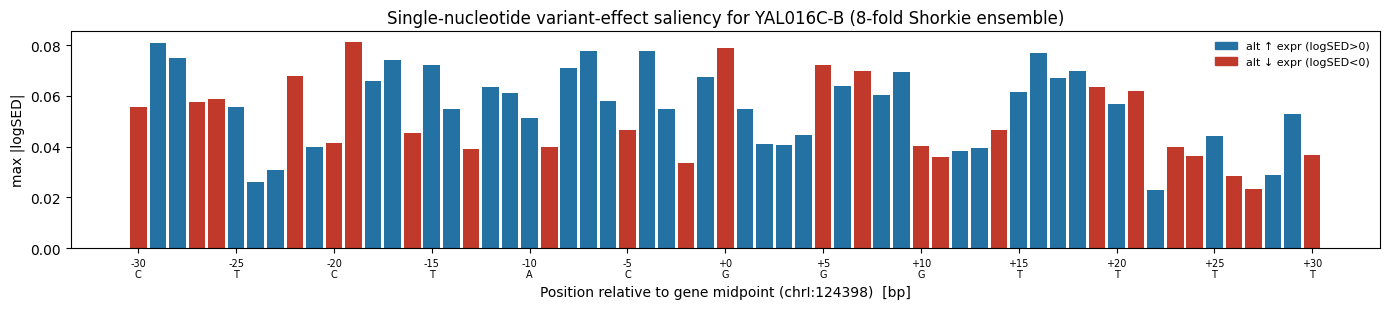

In [7]:
# Plot the per-position max |logSED| saliency track (signed, colored by direction).
fig, ax = plt.subplots(figsize=(14, 3.2))
colors = ["#c0392b" if v < 0 else "#2471a3" for v in signed_peak]
ax.bar(offsets, max_abs, color=colors, width=0.85)

ax.set_xlabel(f"Position relative to gene midpoint ({chrom}:{anchor})  [bp]")
ax.set_ylabel("max |logSED|")
ax.set_title(f"Single-nucleotide variant-effect saliency for {GENE} (8-fold Shorkie ensemble)")
ax.axhline(0, color="k", lw=0.6)

# Annotate the reference base under each scanned position.
ax.set_xticks(offsets[::5])
ax.set_xticklabels([f"{o:+d}\n{b}" for o, b in zip(offsets[::5], np.array(ref_bases)[::5])], fontsize=7)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2471a3", label="alt ↑ expr (logSED>0)"),
                   Patch(color="#c0392b", label="alt ↓ expr (logSED<0)")],
          loc="upper right", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

fasta.close()